In [334]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns

In [335]:
lim_data = pd.read_csv('new_tests.csv')
dome_data = pd.read_csv('flan_without_lim.csv')
lim_data = lim_data.iloc[: , 1:]
dome_data = dome_data.iloc[: , 1:]

In [336]:
def count_keys(cell):
    if pd.isnull(cell): 
        return 0
    try:
        dictionary = ast.literal_eval(cell) 
        if isinstance(dictionary, dict):
            return len(dictionary.keys()) 
    except (ValueError, SyntaxError):
        return 0 
    return 0


In [337]:
def treat(df):
    df = df.iloc[: , 0:]
    df['total_attributes'] = df['expected_attributes'].apply(count_keys) + df['expected_filter_attributes'].apply(count_keys)
    df.expected_attributes = df.expected_attributes.str.lower()
    df.expected_filter_attributes = df.expected_filter_attributes.str.lower()
    df.processed_attributes = df.processed_attributes.str.lower()
    df.processed_filters = df.processed_filters.str.lower()
    df.expected_attributes = df.expected_attributes.fillna('{}')
    df.expected_filter_attributes = df.expected_filter_attributes.fillna('{}')
    return df

In [338]:
dome_data = treat(dome_data)
lim_data = treat(lim_data)
dome_data.head(10)

/tmp/ipykernel_14397/2370718173.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['total_attributes'] = df['expected_attributes'].apply(count_keys) + df['expected_filter_attributes'].apply(count_keys)
/tmp/ipykernel_14397/2370718173.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.expected_attributes = df.expected_attributes.str.lower()
/tmp/ipykernel_14397/2370718173.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_i

,user_msg,expected_intent,expected_class,expected_attributes,expected_filter_attributes,processed_attributes,processed_filters,find_entity,find_intent,total_attributes
0,"add student with name=anderson martins gomes, ...",ADD,student,"{'name': 'anderson martins gomes', 'age': '20'}",{},"{'student': 'student', 'name': 'name', '20': '...",{},anderson_martins_gomes,ADD,2
1,"add subject with name=brazilian history, descr...",ADD,subject,"{'name': 'brazilian history', 'description': '...",{},"{'subject': 'description', 'history': 'descrip...",{},history_of_brazil,ADD,2
2,"add teacher with name=paulo henrique, age=65, ...",ADD,teacher,"{'name': 'paulo henrique', 'age': '65', 'email...",{},"{'teacher': 'name', 'br': 'henrique'}",{},ph_uece_br,ADD,3
3,"add subject with name=math, description=the be...",ADD,subject,"{'name': 'math', 'description': 'the best subj...",{},"{'name': 'name', 'description': 'description',...",{},math,ADD,2
4,"add subject with name=math, description='the b...",ADD,subject,"{'name': 'math', 'description': 'the best subj...",{},"{'name': 'name', 'description': 'description',...",{},math,ADD,2
5,add student name=anderson,ADD,student,{'name': 'anderson'},{},{'student': 'name=anderson'},{},adolescent,ADD,1
6,get students with name anderson,READ,student,{'name': 'anderson'},{},"{'students': 'students', 'name': 'name'}",{},anderson,READ,1
7,show me the teachers,READ,teacher,{},{},{},{},teacher,READ,0
8,show teachers,READ,teacher,{},{},{},{},teacher,READ,0
9,show teacher,READ,teacher,{},{},{'show': 'show'},{},teacher,DELETE,0


In [339]:
def analyze(df):
    objective_analysis = pd.DataFrame()
    objective_analysis['user_msg'] = df['user_msg']
    objective_analysis['intent'] = df.expected_intent
    objective_analysis['att_qnt'] = df.total_attributes
    objective_analysis['correct_intent'] = df.expected_intent == df.find_intent
    objective_analysis['correct_entity'] = df.expected_class == df.find_entity
    objective_analysis['correct_attributes'] = df.expected_attributes == df.processed_attributes
    objective_analysis['correct_filters'] = df.expected_filter_attributes == df.processed_filters
    objective_analysis['correct_answer'] = objective_analysis.correct_intent & objective_analysis.correct_entity & objective_analysis.correct_attributes & objective_analysis.correct_filters
    return objective_analysis

In [340]:
objective_analysis = analyze(dome_data)
objective_analysis

,user_msg,intent,att_qnt,correct_intent,correct_entity,correct_attributes,correct_filters,correct_answer
0,"add student with name=anderson martins gomes, ...",ADD,2,True,False,False,True,False
1,"add subject with name=brazilian history, descr...",ADD,2,True,False,False,True,False
2,"add teacher with name=paulo henrique, age=65, ...",ADD,3,True,False,False,True,False
3,"add subject with name=math, description=the be...",ADD,2,True,False,False,True,False
4,"add subject with name=math, description='the b...",ADD,2,True,False,False,True,False
...,...,...,...,...,...,...,...,...
454,add an invoice with value=100,ADD,1,True,False,False,True,False
455,get all invoice,READ,0,True,True,True,True,True
456,add car with license=2020,ADD,1,True,False,False,True,False
457,add car with color=black,ADD,1,True,False,False,True,False


In [341]:
objective_analysis_lim = analyze(lim_data)
objective_analysis_lim

,user_msg,intent,att_qnt,correct_intent,correct_entity,correct_attributes,correct_filters,correct_answer
0,"add student with name=anderson martins gomes, ...",ADD,2,True,True,True,True,True
1,"add subject with name=brazilian history, descr...",ADD,2,True,True,True,True,True
2,"add teacher with name=paulo henrique, age=65, ...",ADD,3,True,True,False,True,False
3,"add subject with name=math, description=the be...",ADD,2,True,True,True,True,True
4,"add subject with name=math, description='the b...",ADD,2,True,True,True,True,True
...,...,...,...,...,...,...,...,...
454,add an invoice with value=100,ADD,1,True,False,True,True,False
455,get all invoice,READ,0,True,False,False,True,False
456,add car with license=2020,ADD,1,True,True,True,True,True
457,add car with color=black,ADD,1,True,True,True,True,True


In [368]:
data = [{'table': objective_analysis, 'label': 'Without LIM'}, {'table': objective_analysis_lim, 'label': 'With LIM'}]

In [370]:
def get_cor(df):
    cors=[df['correct_intent'].sum(),
          df['correct_entity'].sum(),
          df['correct_attributes'].sum(),
          df['correct_filters'].sum(),
          df['correct_answer'].sum()]
    return cors


In [372]:
def plot_hits(df_list):
    colors = ['skyblue', 'red', 'green'][:len(df_list)]
    fig, ax = plt.subplots()

    df_list_sorted = sorted(
    df_list,
    key=lambda df: sum(get_cor(df['table'])),  
    reverse=True
    )
    
    # Plotar cada DataFrame
    for i, df in enumerate(df_list_sorted):
        ax.bar(['Intent', 'Entity', 'Attributes', 'Filters', 'Total'], 
                get_cor(df['table']), color=colors[i],
                label=df['label'],
                alpha=0.9)
        

    ax.set_title('Comparativo de acertos')
    ax.set_xlabel('Categorias')
    ax.set_ylabel("Acertos")
    ax.legend()
    plt.xticks(rotation=45) 
    plt.tight_layout()
    plt.show()

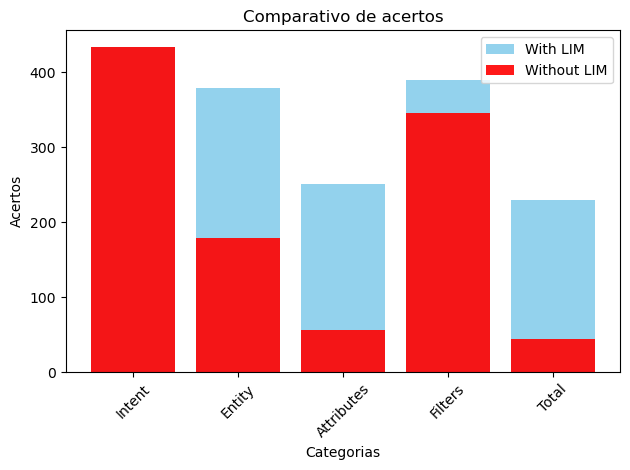

In [374]:
plot_hits(data)

In [416]:
def calculate_acc_by_att(df):
    result = df.groupby('att_qnt')['correct_answer'].sum().reset_index()
    result.columns = ['att_qnt', 'correct_answer']
    total_counts = df['att_qnt'].value_counts().reset_index()
    total_counts.columns = ['att_qnt', 'total_count']
    
    result_percentage = pd.merge(result, total_counts, on='att_qnt')
    
    result_percentage['accuracy_percentage'] = (result_percentage['correct_answer'] / result_percentage['total_count']) * 100
    return result_percentage

In [426]:
def plot_hits_by_att(df_list):

    colors = ['skyblue', 'red', 'green'][:len(df_list)]
    fig, ax = plt.subplots()
    df_list_sorted = sorted(
    df_list,
    key=lambda df: sum(calculate_acc_by_att(df['table'])['accuracy_percentage']),  
    reverse=True
    )
    
    for i, df in enumerate(df_list_sorted):
        frame = calculate_acc_by_att(df['table'])
        ax.bar(frame.att_qnt, 
                frame.accuracy_percentage, 
                color=colors[i],
                label=df['label'],
                alpha=0.9)
        

    ax.set_title('Acertos para cada quantidade de atributos')
    ax.set_xlabel('Quantidade de atributos')
    ax.set_ylabel("Porcentagem de acertos (0-100)")
    ax.legend()
    plt.xticks(rotation=15)  
    plt.tight_layout()
    plt.show()

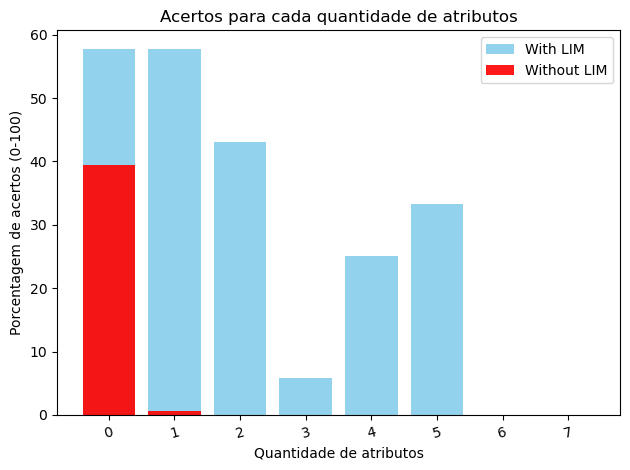

In [428]:
plot_hits_by_att(data)

In [202]:
def acc_by_intent(df):
    result_intent = df.groupby('intent')['correct_answer'].sum().reset_index()
    result_intent.columns = ['intent', 'correct_answer']
    total_counts_intent = df['intent'].value_counts().reset_index()
    total_counts_intent.columns = ['intent', 'total_count']
    result_intent_percentage = pd.merge(result_intent, total_counts_intent, on='intent')
    result_intent_percentage['accuracy_percentage'] = (result_intent_percentage['correct_answer'] / result_intent_percentage['total_count']) * 100
    return result_intent_percentage

In [434]:
def plot_hits_by_opr(df_list):
    colors = ['skyblue', 'red', 'green'][:len(df_list)]
    fig, ax = plt.subplots()
    df_list_sorted = sorted(
    df_list,
    key=lambda df: sum(acc_by_intent(df['table'])['accuracy_percentage']),  
    reverse=True
    )
    
    for i, df in enumerate(df_list_sorted):
        frame = acc_by_intent(df['table'])
        ax.bar(frame.intent, 
                frame.accuracy_percentage, 
                color=colors[i],
                label=df['label'],
                alpha=0.9)
        

    ax.set_title('Acertos para cada quantidade de atributos')
    ax.set_xlabel('Quantidade de atributos')
    ax.set_ylabel("Porcentagem de acertos (0-100)")
    ax.legend()
    plt.xticks(rotation=15)  
    plt.tight_layout()
    plt.show()

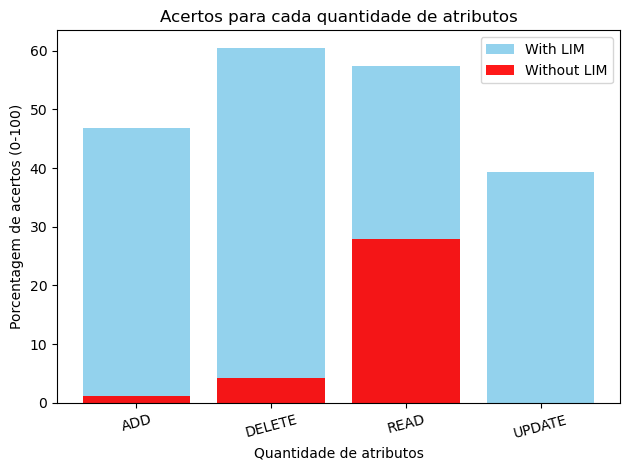

In [436]:
plot_hits_by_opr(data)

In [460]:
def get(df):
    intent_totals = df.groupby("intent").size().reset_index(name="total_count")

    columns_to_count = ["correct_intent", "correct_entity", "correct_attributes", "correct_filters"]
    grouped_data = df.groupby("intent")[columns_to_count].sum().reset_index()
    
    grouped_data = pd.merge(grouped_data, intent_totals, on="intent")
    for col in columns_to_count:
        grouped_data[f"{col}_percentage"] = (grouped_data[col] / grouped_data["total_count"]) * 100
    
    percentage_columns = [f"{col}_percentage" for col in columns_to_count]
    plot_data = grouped_data.set_index("intent")[percentage_columns]
    return plot_data

In [466]:
def acc_by_opr_cat(df):
    print(get(df[0]['table']))
    colors = ['skyblue', 'red', 'green'][:len(df_list)]
    fig, ax = plt.subplots()
    df_list_sorted = sorted(
    df_list,
    key=lambda df: sum(acc_by_intent(df['table'])['accuracy_percentage']),  
    reverse=True
    )
    
    for i, df in enumerate(df_list_sorted):
        frame = acc_by_intent(df['table'])
        ax.bar(frame.intent, 
                frame.accuracy_percentage, 
                color=colors[i],
                label=df['label'],
                alpha=0.9)
        

    ax.set_title('Acertos para cada quantidade de atributos')
    ax.set_xlabel('Quantidade de atributos')
    ax.set_ylabel("Porcentagem de acertos (0-100)")
    ax.legend()
    plt.xticks(rotation=15)  
    plt.tight_layout()
    plt.show()

    
    intent_totals = df.groupby("intent").size().reset_index(name="total_count")

    columns_to_count = ["correct_intent", "correct_entity", "correct_attributes", "correct_filters"]
    grouped_data = df.groupby("intent")[columns_to_count].sum().reset_index()
    
    grouped_data = pd.merge(grouped_data, intent_totals, on="intent")
    for col in columns_to_count:
        grouped_data[f"{col}_percentage"] = (grouped_data[col] / grouped_data["total_count"]) * 100
    
    percentage_columns = [f"{col}_percentage" for col in columns_to_count]
    plot_data = grouped_data.set_index("intent")[percentage_columns]
    
    plot_data.plot(kind="bar", figsize=(10, 6), stacked=False, color=["skyblue", "orange", "green", "red"])
    
    plt.title("Porcentagem de acertos por categoria e intenção")
    plt.xlabel("Intent")
    plt.ylabel("Porcentagem de acertos (%)")
    plt.legend(title="Categorias", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

In [468]:
acc_by_opr_cat(data)

        correct_intent_percentage  correct_entity_percentage  \
intent                                                         
ADD                     97.633136                  13.609467   
DELETE                 100.000000                  68.750000   
READ                    89.510490                  42.657343   
UPDATE                  93.939394                  62.626263   

        correct_attributes_percentage  correct_filters_percentage  
intent                                                             
ADD                          1.183432                   98.224852  
DELETE                       8.333333                   97.916667  
READ                        32.867133                   93.006993  
UPDATE                       3.030303                    0.000000  


NameError: name 'df_list' is not defined

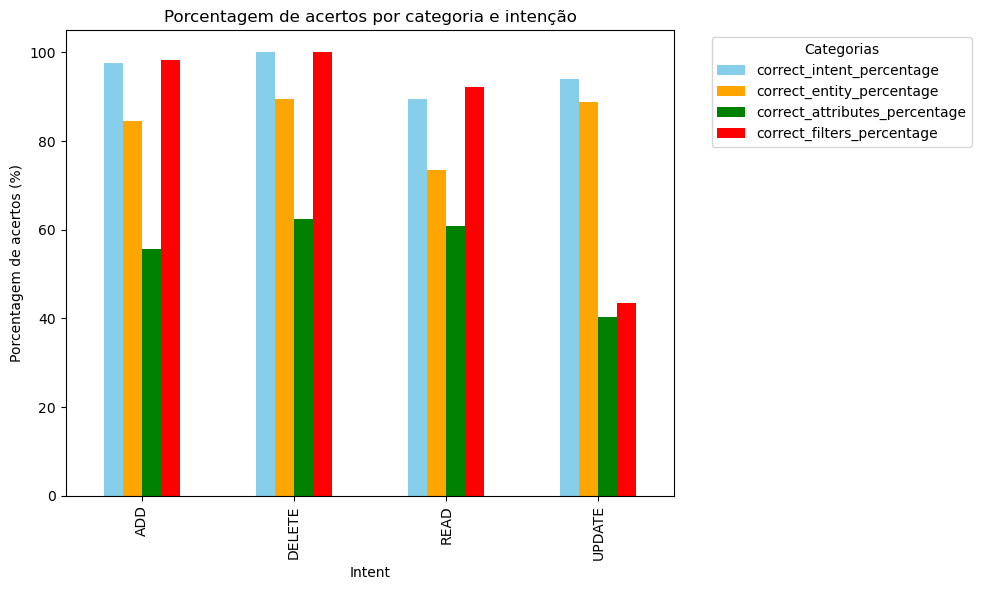

In [216]:
acc_by_opr_cat(objective_analysis_lim)

In [218]:
def acc_by_cat_att(df):
    att_totals = df.groupby("att_qnt").size().reset_index(name="total_count")

    columns_to_count = ["correct_intent", "correct_entity", "correct_attributes", "correct_filters"]
    grouped_data = df.groupby("att_qnt")[columns_to_count].sum().reset_index()
    grouped_data = pd.merge(grouped_data, att_totals, on="att_qnt")
    for col in columns_to_count:
        grouped_data[f"{col}_percentage"] = (grouped_data[col] / grouped_data["total_count"]) * 100
    percentage_columns = [f"{col}_percentage" for col in columns_to_count]
    
    plot_data = grouped_data.set_index("att_qnt")[percentage_columns]
    
    plot_data.plot(kind="bar", figsize=(10, 6), stacked=False, color=["skyblue", "orange", "green", "red"])
    
    plt.title("Porcentagem de acertos por categoria e quantidade de atributos")
    plt.xlabel("Quantidade de atributos")
    plt.ylabel("Porcentagem de acertos (%)")
    plt.legend(title="Categorias", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

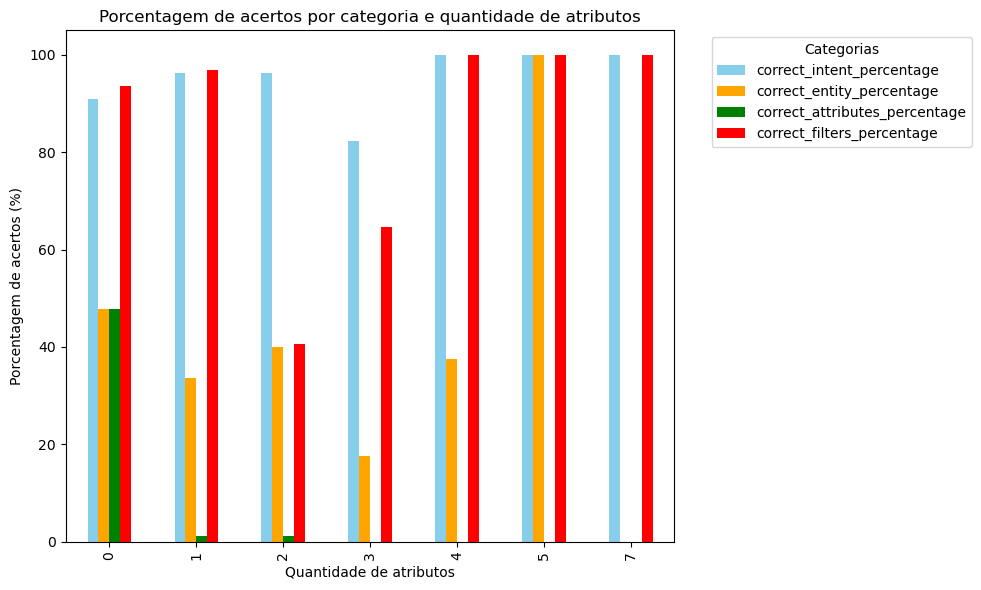

In [220]:
acc_by_cat_att(objective_analysis)

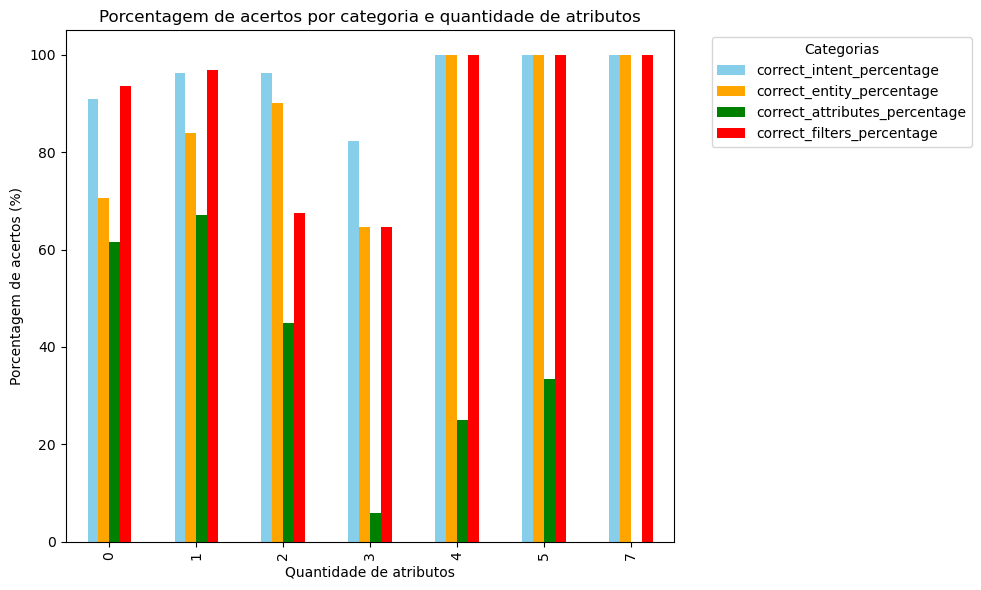

In [222]:
acc_by_cat_att(objective_analysis_lim)